# LiveCodeBench Preprocessing — Code Generation Task

In [2]:
import matplotlib.pyplot as plt

import json
import base64
import zlib
import pickle
from pathlib import Path

import pandas as pd
from datasets import load_dataset

## STEP 1: Load LiveCodeBench Dataset from Hugging Face

In [3]:
# Load the dataset directly from the URL
url = "https://huggingface.co/datasets/livecodebench/code_generation_lite/resolve/main/test6.jsonl"
ds = load_dataset("json", data_files=url)

# Access the 'train' split
train_split = ds["train"]

# Convert the 'train' split to a Pandas DataFrame
df_raw = train_split.to_pandas()
df = df_raw.copy()
df.head()

,question_title,question_content,platform,question_id,contest_id,contest_date,starter_code,difficulty,public_test_cases,private_test_cases,metadata
0,9x9 Sum,Among the 81 integers that appear in the 9-by-...,atcoder,abc387_b,abc387,2025-01-04,,easy,"[{""input"": ""1"", ""output"": ""2024"", ""testtype"": ...",eJy9lUEKwjAQRRVc6C1K1kUyaZM0nkRQd3bRTS2YLkQED6...,{}
1,Count Arrays,"You are given positive integers N, M, and a se...",atcoder,abc387_f,abc387,2025-01-04,,hard,"[{""input"": ""3 3\n2 1 1"", ""output"": ""6"", ""testt...",eJyl/UvOLcmSpQeyUQPZiHaCMFNVM1XlSAqoqF6xkZ1LAg...,{}
2,Happy New Year 2025,You are given two positive integers A and B.\n...,atcoder,abc387_a,abc387,2025-01-04,,easy,"[{""input"": ""20 25"", ""output"": ""2025"", ""testtyp...",eJydVktqHFEMzCKb3EL02gT9nvReThJwsosX3kwMbi9MCO...,{}
3,Snake Numbers,A positive integer not less than 10 whose top ...,atcoder,abc387_c,abc387,2025-01-04,,medium,"[{""input"": ""97 210"", ""output"": ""6"", ""testtype""...",eJyNVr2qVGkQ3MBsX+JjYln6/8cnEXSzNTC5KzgGIoKhmY...,{}
4,Coming of Age Celebration,"On a certain planet, there are N aliens, all o...",atcoder,abc388_d,abc388,2025-01-11,,medium,"[{""input"": ""4\n5 0 9 3"", ""output"": ""2 0 10 5"",...",eJyMvc2ubU2znEWDC1mcthuj/qu4EiTcxA13DpZ83EDIEt...,{}


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   question_title      175 non-null    str          
 1   question_content    175 non-null    str          
 2   platform            175 non-null    str          
 3   question_id         175 non-null    str          
 4   contest_id          175 non-null    str          
 5   contest_date        175 non-null    datetime64[s]
 6   starter_code        175 non-null    str          
 7   difficulty          175 non-null    str          
 8   public_test_cases   175 non-null    str          
 9   private_test_cases  175 non-null    str          
 10  metadata            175 non-null    str          
dtypes: datetime64[s](1), str(10)
memory usage: 128.0 MB


## STEP 2: Handle Missing Values & Malformed Rows

Empty strings need to become real `NaN`s before we can reason about what's actually missing.

In [5]:
# Replace empty strings with NaN so missing-value checks are meaningful

df = df.replace("", pd.NA)

print("Missing values per column:")

print(df.isna().sum())

Missing values per column:
question_title          0
question_content        0
platform                0
question_id             0
contest_id              0
contest_date            0
starter_code          112
difficulty              0
public_test_cases       0
private_test_cases      0
metadata                0
dtype: int64


`starter_code` being empty just means the problem gives the model no scaffold to start from — that's expected, not a data quality issue, so we fill it with `""` rather than dropping those rows.

`question_content` and `public_test_cases` are different: a task with no prompt or no visible test cases isn't usable, so those rows get dropped. We also de-duplicate on `question_id` in case the same problem shows up twice.

In [6]:
# starter_code missing just means "no scaffold" -> fill with empty string
df["starter_code"] = df["starter_code"].fillna("")



# Drop rows that are missing the actual problem statement or public test cases
before = len(df)
df = df.dropna(subset=["question_content", "public_test_cases"]).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows missing a prompt or public test cases")

# De-duplicate on question_id
before = len(df)
df = df.drop_duplicates(subset=["question_id"]).reset_index(drop=True)

print(f"Dropped {before - len(df)} duplicate question_id rows")
print(f"Remaining tasks: {len(df)}")

Dropped 0 rows missing a prompt or public test cases
Dropped 0 duplicate question_id rows
Remaining tasks: 175


## STEP 3: Parse Test Cases (Public + Private)

`public_test_cases` is always a plain JSON string. `private_test_cases` is trickier — LiveCodeBench stores it as plain JSON *or*, when the test set is large, as a zlib-compressed, base64-encoded, pickled blob. The function below tries plain JSON first and falls back to the compressed path, so it handles both without needing to know in advance which one a given row uses.

In [7]:
def parse_public_test_cases(raw):
    if isinstance(raw, list):          # already parsed
        return raw
    try:
        return json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        print(f"Failed to parse public test cases: {str(raw)[:50]}...")
        return []


def parse_private_test_cases(raw):
    if isinstance(raw, list):          # already parsed
        return raw
    if not isinstance(raw, str) or raw == "":
        print("empty string")
        return []
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass
    try:
        decoded = base64.b64decode(raw)
        decompressed = zlib.decompress(decoded)
        return json.loads(pickle.loads(decompressed))
    except Exception as e:
        print(f"Failed to parse private test cases ({type(e).__name__}): {raw[:50]}...")
        return []


df["public_test_cases"] = df["public_test_cases"].apply(parse_public_test_cases)
df["private_test_cases"] = df["private_test_cases"].apply(parse_private_test_cases)

df["num_public_test_cases"] = df["public_test_cases"].apply(len)
df["num_private_test_cases"] = df["private_test_cases"].apply(len)


# Sanity check: flag any rows where private test cases failed to parse (both plain and compressed)
n_empty_private = (df["num_private_test_cases"] == 0).sum()

print(f"Rows with 0 parsed private test cases: {n_empty_private} / {len(df)}")

df[["num_public_test_cases", "num_private_test_cases"]].describe()

Rows with 0 parsed private test cases: 0 / 175


,num_public_test_cases,num_private_test_cases
count,175.000000,175.000000
mean,2.645714,37.354286
std,0.758228,8.197993
min,1.000000,1.000000
25%,2.000000,40.000000
50%,3.000000,40.000000
75%,3.000000,40.000000
max,5.000000,40.000000


In [8]:
df[['num_public_test_cases','public_test_cases']]

,num_public_test_cases,public_test_cases
0,3,"[{'input': '1', 'output': '2024', 'testtype': ..."
1,3,"[{'input': '3 3 2 1 1', 'output': '6', 'testty..."
2,4,"[{'input': '20 25', 'output': '2025', 'testtyp..."
3,3,"[{'input': '97 210', 'output': '6', 'testtype'..."
4,3,"[{'input': '4 5 0 9 3', 'output': '2 0 10 5', ..."
...,...,...
170,4,"[{'input': '[1, 2, 3, 4]', 'output': '12', 'te..."
171,2,"[{'input': '[""jump"", ""run"", ""run"", ""jump"", ""ru..."
172,2,"[{'input': '""abc""', 'output': '148', 'testtype..."
173,4,"[{'input': '""01""', 'output': '1', 'testtype': ..."


## STEP 4: Build the Model-Ready Prompt

This is the actual string a baseline model will see: the problem statement plus any starter code, concatenated the same way for every task.

In [9]:
def build_prompt(row):
    """Concatenate the problem statement with any starter code — this is what gets sent to the model."""
    prompt = row["question_content"].strip()

    if row["starter_code"].strip():
        prompt += "\n\n" + row["starter_code"].strip()
    return prompt


df["prompt"] = df.apply(build_prompt, axis=1)
df["prompt_length_chars"] = df["prompt"].str.len()
df["prompt_length_words"] = df["prompt"].str.split().apply(len)
df

,question_title,question_content,platform,question_id,contest_id,contest_date,starter_code,difficulty,public_test_cases,private_test_cases,metadata,num_public_test_cases,num_private_test_cases,prompt,prompt_length_chars,prompt_length_words
0,9x9 Sum,Among the 81 integers that appear in the 9-by-...,atcoder,abc387_b,abc387,2025-01-04 00:00:00,,easy,"[{'input': '1', 'output': '2024', 'testtype': ...","[{'input': '26', 'output': '2025 ', 'testtype'...",{},3,40,Among the 81 integers that appear in the 9-by-...,1070,213
1,Count Arrays,"You are given positive integers N, M, and a se...",atcoder,abc387_f,abc387,2025-01-04 00:00:00,,hard,"[{'input': '3 3 2 1 1', 'output': '6', 'testty...","[{'input': '4 1 3 4 4 1', 'output': '1 ', 'tes...",{},3,40,"You are given positive integers N, M, and a se...",856,164
2,Happy New Year 2025,You are given two positive integers A and B.\n...,atcoder,abc387_a,abc387,2025-01-04 00:00:00,,easy,"[{'input': '20 25', 'output': '2025', 'testtyp...","[{'input': '1 1', 'output': '4 ', 'testtype': ...",{},4,40,You are given two positive integers A and B.\n...,455,84
3,Snake Numbers,A positive integer not less than 10 whose top ...,atcoder,abc387_c,abc387,2025-01-04 00:00:00,,medium,"[{'input': '97 210', 'output': '6', 'testtype'...","[{'input': '408262943519 818514521103', 'outpu...",{},3,40,A positive integer not less than 10 whose top ...,785,136
4,Coming of Age Celebration,"On a certain planet, there are N aliens, all o...",atcoder,abc388_d,abc388,2025-01-11 00:00:00,,medium,"[{'input': '4 5 0 9 3', 'output': '2 0 10 5', ...","[{'input': '6 9 32 37 39 10 50', 'output': '4 ...",{},3,40,"On a certain planet, there are N aliens, all o...",1315,284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,unique-3-digit-even-numbers,You are given an array of digits called digits...,leetcode,3799,biweekly-contest-152,2025-03-15 07:30:00,"class Solution:\n def totalNumbers(self, di...",easy,"[{'input': '[1, 2, 3, 4]', 'output': '12', 'te...","[{'input': '[2,1,8,8,1,6,9,9,6,5]', 'output': ...","{""func_name"": ""totalNumbers""}",4,31,You are given an array of digits called digits...,1042,184
171,longest-common-prefix-of-k-strings-after-removal,You are given an array of strings words and an...,leetcode,3784,biweekly-contest-152,2025-03-15 07:30:00,class Solution:\n def longestCommonPrefix(s...,hard,"[{'input': '[""jump"", ""run"", ""run"", ""jump"", ""ru...","[{'input': '[""fdcc"",""ccfef"",""acaa"",""adfa"",""afc...","{""func_name"": ""longestCommonPrefix""}",2,40,You are given an array of strings words and an...,1775,270
172,reverse-degree-of-a-string,"Given a string s, calculate its reverse degree...",leetcode,3811,biweekly-contest-153,2025-03-29 07:30:00,"class Solution:\n def reverseDegree(self, s...",easy,"[{'input': '""abc""', 'output': '148', 'testtype...","[{'input': '""mwabhohzpwbaqzdaqrxeqitspsqctowzn...","{""func_name"": ""reverseDegree""}",2,31,"Given a string s, calculate its reverse degree...",893,165
173,maximize-active-section-with-trade-i,"You are given a binary string s of length n, w...",leetcode,3805,biweekly-contest-153,2025-03-29 07:30:00,class Solution:\n def maxActiveSectionsAfte...,medium,"[{'input': '""01""', 'output': '1', 'testtype': ...","[{'input': '""111111111111111111111111111111111...","{""func_name"": ""maxActiveSectionsAfterTrade""}",4,40,"You are given a binary string s of length n, w...",1694,284


## STEP 5: Sanity-Check Plots

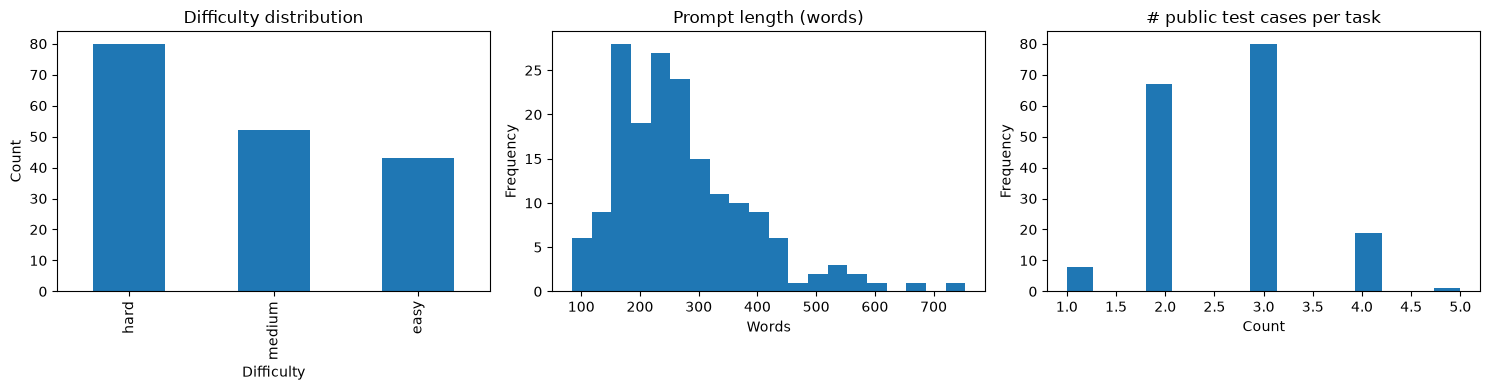

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


df["difficulty"].value_counts().plot(kind="bar", ax=axes[0], title="Difficulty distribution")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Count")

df["prompt_length_words"].plot(kind="hist", bins=20, ax=axes[1], title="Prompt length (words)")
axes[1].set_xlabel("Words")
df["num_public_test_cases"].plot(kind="hist", bins=15, ax=axes[2], title="# public test cases per task")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

## STEP 6: Tag Task Type & Finalize Schema

`task_type` and `source_dataset` are here so this lines up with however the other datasets (HumanEval, SWE-bench bug-fixes) get tagged — the Router agent planned for October needs a reliable task-type label to dispatch on. `difficulty` is kept as-is (not just one-hot encoded) since the Evaluator rubric will likely want to break results down by difficulty.

In [11]:
df["task_type"] = "code_generation"
df["source_dataset"] = "livecodebench"

# One-hot difficulty for quick grouping/plotting -- we keep the original `difficulty` column too
difficulty_encoded = pd.get_dummies(df["difficulty"], prefix="difficulty")

df = pd.concat([df, difficulty_encoded], axis=1)


final_columns = [
    "task_type", "source_dataset", "question_id", 
    "question_title",
    "difficulty",
    "prompt", "starter_code",
    "public_test_cases",
    "private_test_cases",
]

df_final = df[final_columns].copy()

df_final.head()

,task_type,source_dataset,question_id,question_title,difficulty,prompt,starter_code,public_test_cases,private_test_cases
0,code_generation,livecodebench,abc387_b,9x9 Sum,easy,Among the 81 integers that appear in the 9-by-...,,"[{'input': '1', 'output': '2024', 'testtype': ...","[{'input': '26', 'output': '2025 ', 'testtype'..."
1,code_generation,livecodebench,abc387_f,Count Arrays,hard,"You are given positive integers N, M, and a se...",,"[{'input': '3 3 2 1 1', 'output': '6', 'testty...","[{'input': '4 1 3 4 4 1', 'output': '1 ', 'tes..."
2,code_generation,livecodebench,abc387_a,Happy New Year 2025,easy,You are given two positive integers A and B.\n...,,"[{'input': '20 25', 'output': '2025', 'testtyp...","[{'input': '1 1', 'output': '4 ', 'testtype': ..."
3,code_generation,livecodebench,abc387_c,Snake Numbers,medium,A positive integer not less than 10 whose top ...,,"[{'input': '97 210', 'output': '6', 'testtype'...","[{'input': '408262943519 818514521103', 'outpu..."
4,code_generation,livecodebench,abc388_d,Coming of Age Celebration,medium,"On a certain planet, there are N aliens, all o...",,"[{'input': '4 5 0 9 3', 'output': '2 0 10 5', ...","[{'input': '6 9 32 37 39 10 50', 'output': '4 ..."


## STEP 7: Save the Processed Dataset

Saved as JSONL (not Parquet) because `public_test_cases` / `private_test_cases` are nested lists of dicts, which Parquet's schema inference handles poorly but JSONL handles natively.

In [12]:
output_dir = Path("../data/code_generation/livecodebench")

output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "livecodebench_processed.jsonl"
df_final.to_json(output_path, orient="records", lines=True)

print(f"Saved {len(df_final)} processed tasks to {output_path}")

Saved 175 processed tasks to ../data/code_generation/livecodebench/livecodebench_processed.jsonl


## STEP 8: Final Check — Ready for Baseline Model Testing

In [13]:
print(f"Final dataset: {len(df_final)} tasks, {df_final['question_id'].nunique()} unique problems")

sample = df_final.iloc[0]
print("\n--- Sample prompt that would be sent to a baseline model ---\n")
print(sample['prompt'][:600])

Final dataset: 175 tasks, 175 unique problems

--- Sample prompt that would be sent to a baseline model ---

Among the 81 integers that appear in the 9-by-9 multiplication table, find the sum of those that are not X.

There is a grid of size 9 by 9.
Each cell of the grid contains an integer: the cell at the i-th row from the top and the j-th column from the left contains i \times j.
You are given an integer X. Among the 81 integers written in this grid, find the sum of those that are not X. If the same value appears in multiple cells, add it for each cell.

Input

The input is given from Standard Input in the following format:
X

Output

Print the sum of the integers that are not X among the 81 int
